**The model arch and training:**

- Core Architecture:          2D U-Net (Symmetric Encoder-Decoder)

- Encoder Backbone:           ResNet-34 (Pre-trained on ImageNet)

- Input Dimensions:           17×256×256 (Multispectral Satellite Channels)

- Output Dimensions:          240×256×256 (Interpreted as 3 variables×80 Z-bins)

- Convolutions:               3×3 2D Convolutions with Batch Normalization

- Activation Function:        ReLU (Hidden Layers) / Linear (Output Layer)

- Optimizer:                  AdamW (Weight Decay: 1×10−2)

- Learning Rate Scheduler:    Cosine Annealing (Tmax​=100, ηmin​=1×10−6)

- Loss Function:              Masked Mean Squared Error (MSE) with 100× Gradient Booster

- Data Augmentation:          Random Horizontal and Vertical Flips (Spatially Aligned)

- Precision:                  16-bit Mixed Precision (FP16)

In [ ]:
import pickle
import glob
import random
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch import seed_everything
import segmentation_models_pytorch as smp

# --- Global Settings ---
torch.set_float32_matmul_precision('medium')
seed_everything(43, workers=True)

# ==========================================
# 1. DATASET WITH SAFE AUGMENTATION
# ==========================================
class BatchedPickleDataset(Dataset):
    def __init__(self, pickle_files, augment=False):
        self.pickle_files = pickle_files
        self.augment = augment

    def __len__(self):
        return len(self.pickle_files)

    def __getitem__(self, idx):
        try:
            with open(self.pickle_files[idx], 'rb') as f:
                data = pickle.load(f)
            if isinstance(data, list):
                data = data[0]
            
            img = data["image"].float()           # (17, 256, 256)
            target = data["cloudsat"].float()     # (Var, Len, Z)
            mask = data["overpass_mask"].float()  # (256, 256)

            if self.augment:
                # 1. Random Horizontal Flip
                if random.random() > 0.5:
                    img = torch.flip(img, dims=[-1])
                    mask = torch.flip(mask, dims=[-1])
                    # Flip chronological sequence of the track
                    target = torch.flip(target, dims=[1]) 

                # 2. Random Vertical Flip
                if random.random() > 0.5:
                    img = torch.flip(img, dims=[-2])
                    mask = torch.flip(mask, dims=[-2])
                    # Flipped vertically still changes the order the satellite 'hits' pixels
                    target = torch.flip(target, dims=[1])

            return {
                "image": img,
                "cloudsat": target,
                "overpass_mask": mask
            }
        except Exception as e:
            print(f"Error loading {self.pickle_files[idx]}: {e}")
            return None

# ==========================================
# 2. 3D RECONSTRUCTION MODEL
# ==========================================
class Cloud3DFullSceneModel(pl.LightningModule):
    def __init__(self, in_channels=17, variables=3, z_bins=80, encoder_name="resnet34", lr=1e-4):
        super().__init__()
        self.save_hyperparameters()
        
        self.net = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights="imagenet", 
            in_channels=in_channels,
            classes=variables * z_bins, 
            activation=None,            
        )

    def forward(self, x):
        pred = self.net(x) 
        return pred.view(-1, self.hparams.variables, self.hparams.z_bins, x.shape[2], x.shape[3])

    def get_aligned_profiles(self, batch):
        cs_target = batch["cloudsat"]         
        overpass_mask = batch["overpass_mask"] 
        pred_volume = self(batch["image"])     

        batch_size = cs_target.shape[0] if cs_target.ndim > 3 else 1
        # Handle Lightning's potential unbatched input during certain steps
        if cs_target.ndim == 3:
            cs_target = cs_target.unsqueeze(0)
            overpass_mask = overpass_mask.unsqueeze(0)
            pred_volume = pred_volume.unsqueeze(0)

        aligned_preds = []
        aligned_targets = []

        for i in range(batch_size):
            coords = torch.nonzero(overpass_mask[i])
            if coords.shape[0] == 0: continue
            
            sorted_idx = torch.argsort(coords[:, 0]) 
            coords = coords[sorted_idx]
            y, x = coords[:, 0], coords[:, 1]

            p_profile = pred_volume[i, :, :, y, x] 
            t_profile = cs_target[i].permute(0, 2, 1)
            
            finite_mask = torch.isfinite(t_profile[0, 0, :])
            t_profile = t_profile[:, :, finite_mask]

            min_len = min(p_profile.shape[2], t_profile.shape[2])
            if min_len < 2: continue

            aligned_preds.append(p_profile[:, :, :min_len])
            aligned_targets.append(t_profile[:, :, :min_len])

        return aligned_preds, aligned_targets

    def training_step(self, batch, batch_idx):
        preds, targets = self.get_aligned_profiles(batch)
        if not preds: return None

        mse_list = []
        for p, t in zip(preds, targets):
            mse_list.append(F.mse_loss(p, t) * 100.0)
        
        loss = torch.stack(mse_list).mean()
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        preds, targets = self.get_aligned_profiles(batch)
        if not preds: return None

        mse_list = []
        for p, t in zip(preds, targets):
            mse_list.append(F.mse_loss(p, t) * 100.0)
        
        loss = torch.stack(mse_list).mean()
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-2)
        scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"}
        }

# ==========================================
# 3. EXECUTION
# ==========================================
if __name__ == "__main__":
    PICKLE_PATH = r"C:\Users\janni\Documents\00_eagle\ELLIS\Challenges\ch10-3d-hurricane-generation-main\src\finetuning\finetune\*.pkl"
    all_pickles = glob.glob(PICKLE_PATH)
    random.shuffle(all_pickles)
    
    train_files = all_pickles[:int(len(all_pickles)*0.8)]
    val_files = all_pickles[int(len(all_pickles)*0.8):]

    # Augment=True for Training, False for Validation
    workers = 0

    train_dl = DataLoader(
        BatchedPickleDataset(train_files, augment=True), 
        batch_size=None, 
        shuffle=True, 
        num_workers=workers,
        persistent_workers=True if workers > 0 else False
    )
    
    val_dl = DataLoader(
        BatchedPickleDataset(val_files, augment=False), 
        batch_size=None, 
        shuffle=False, 
        num_workers=workers,
        persistent_workers=True if workers > 0 else False
    )

    logger = CSVLogger(save_dir="./logs/", name="cloud_3d_finetune")
    checkpoint_cb = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=2)

    trainer = pl.Trainer(
        accelerator="gpu", 
        devices=1, 
        max_epochs=100, 
        callbacks=[checkpoint_cb],
        logger=logger,
        precision="16-mixed",
        log_every_n_steps=1 
    )

    trainer.fit(Cloud3DFullSceneModel(lr=1e-4), train_dl, val_dl)

Seed set to 43
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net  │ Unet │ 24.5 M │ train │     0 │
└───┴──────┴──────┴────────┴───────┴───────┘

Trainable params: 24.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.5 M                                                                                               
Total estimated model params size (MB): 98                                                                         
Modules in train mode: 188                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=100` reached.


**This script is just for visualising the loss curve:**

Reading logs from: ./logs/cloud_3d_finetune\version_15
Max epoch found in file: 99


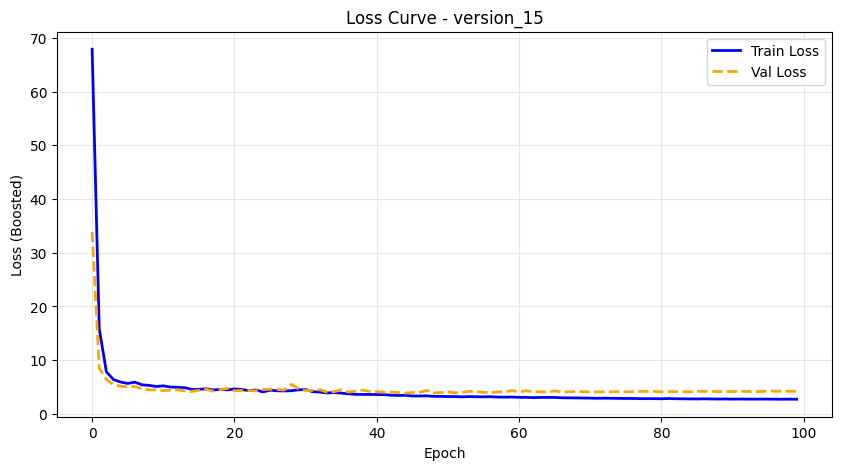

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def plot_latest_loss(log_dir="./logs/cloud_3d_finetune/"):
    # 1. Find ALL version folders and pick the newest one
    folders = [f for f in glob.glob(os.path.join(log_dir, "version_*")) if os.path.isdir(f)]
    if not folders:
        print("No log folders found!")
        return
    
    # Sort by the version number (integer) rather than string to get the true latest
    latest_version = sorted(folders, key=lambda x: int(x.split('_')[-1]))[-1]
    metrics_path = os.path.join(latest_version, "metrics.csv")
    
    print(f"Reading logs from: {latest_version}")
    
    df = pd.read_csv(metrics_path)

    # 2. Extract Validation Loss (logged once per epoch)
    # Filter rows where val_loss exists
    val_df = df.dropna(subset=['val_loss'])
    
    # 3. Extract Training Loss (use the epoch-level average)
    train_df = df.dropna(subset=['train_loss_epoch'])

    # 4. Plot
    plt.figure(figsize=(10, 5))
    
    if not train_df.empty:
        plt.plot(train_df['epoch'], train_df['train_loss_epoch'], label='Train Loss', color='blue', lw=2)
    
    if not val_df.empty:
        plt.plot(val_df['epoch'], val_df['val_loss'], label='Val Loss', color='orange', linestyle='--', lw=2)

    plt.title(f"Loss Curve - {os.path.basename(latest_version)}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (Boosted)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Confirm the max epoch found
    max_epoch = df['epoch'].max()
    print(f"Max epoch found in file: {max_epoch}")
    
    plt.show()

plot_latest_loss()

**This script is just for visual confirmation of the results:**

Visualizing clouds above value: -0.1410 (98th percentile)


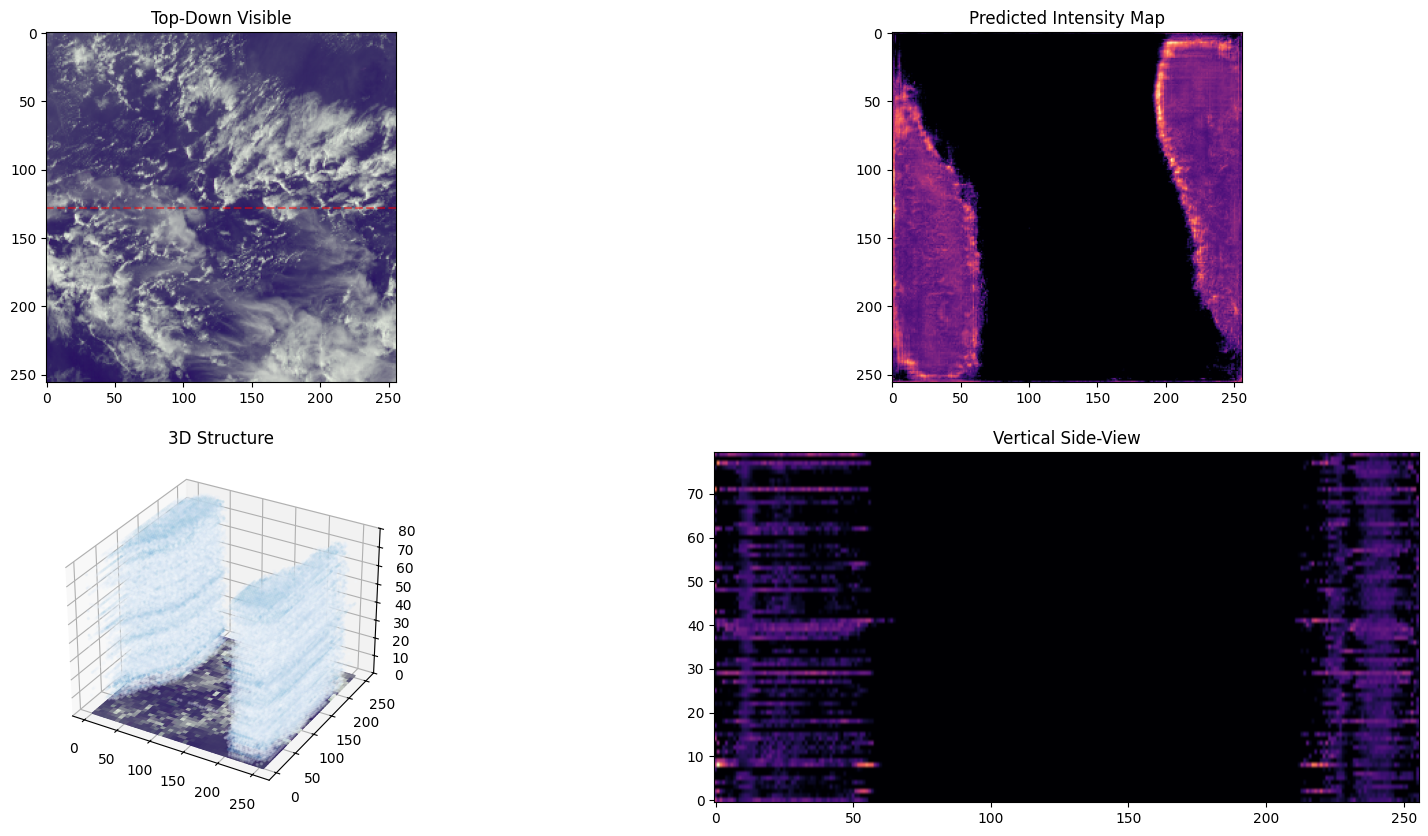

In [50]:
import numpy as np

def visualize_dynamic_hurricane(model, dataloader, device="cuda", cut_y=128):
    model.eval()
    model.to(device)
    
    batch = next(iter(dataloader))
    images = batch["image"].to(device)
    
    with torch.no_grad():
        preds = model(images)
    
    sample_idx = 0
    img_2d = images[sample_idx].cpu().numpy()
    vol_3d = preds[sample_idx, 0].cpu().numpy() 

    # 1. RGB Reconstruction
    r, g = img_2d[0], img_2d[1]
    b = r * 0.8
    rgb = np.stack([r, g, b], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    rgb = np.power(rgb, 1/2.2)

    # 2. DYNAMIC THRESHOLDING
    # We pick the 98th percentile to show the main cloud bodies
    # Anything below this is considered "clear sky" by the visualizer
    thresh = np.percentile(vol_3d, 80) 
    print(f"Visualizing clouds above value: {thresh:.4f} (98th percentile)")

    fig = plt.figure(figsize=(20, 10))
    
    # Top-Down RGB
    ax1 = fig.add_subplot(221)
    ax1.imshow(rgb)
    ax1.axhline(cut_y, color='red', linestyle='--', alpha=0.5)
    ax1.set_title("Top-Down Visible")
    

    # Top-Down Max Reflectivity (The 'Radar' View)
    ax2 = fig.add_subplot(222)
    composite = np.max(vol_3d, axis=0)
    ax2.imshow(composite, cmap='magma', vmin=thresh)
    ax2.set_title("Predicted Intensity Map")

    # 3D Voxel View
    ax3 = fig.add_subplot(223, projection='3d')
    x, y = np.meshgrid(np.arange(256), np.arange(256))
    ax3.plot_surface(x, y, np.zeros_like(x), facecolors=rgb, shade=False)
    
    # Filter volume for 3D scatter
    cloud_mask = vol_3d > thresh
    z, y_idx, x_idx = np.where(cloud_mask[:, ::4, ::4])
    ax3.scatter(x_idx * 4, y_idx * 4, z, c=vol_3d[z, y_idx*4, x_idx*4], 
                cmap='Blues', alpha=0.2, s=2)
    ax3.set_zlim(0, 80)
    ax3.set_title("3D Structure")

    # Vertical Cross-Section
    ax4 = fig.add_subplot(224)
    ax4.imshow(vol_3d[:, cut_y, :], origin='lower', aspect='auto', cmap='magma', vmin=thresh)
    ax4.set_title("Vertical Side-View")

    plt.show()

visualize_dynamic_hurricane(model, val_dl)